# AI Impact on Jobs & Salary Trends
## Phase 2 - Modeling, Evaluation & Insights

This notebook focuses on building machine learning models using the prepared dataset.

We perform:
- Classification (job survival prediction)
- Regression (salary prediction)
- Hyperparameter Tuning
- Clustering (K-Means)
- Anomaly Detection (Isolation Forest)
- PCA Dimensionality Reduction
- Feature Selection Impact
- Business Insights

Additionally, we compare performance using:
- Full feature dataset
- Top-K selected features dataset

This allows us to evaluate the impact of feature selection on model performance.

| Category | Technique | Task |
|---|---|---|
| Classification | Logistic Regression, Random Forest | Predict `job_survival_class` |
| Regression | Linear Regression, Random Forest | Predict `salary` |
| Clustering | K-Means | Discover job-market groups |
| Anomaly Detection | Isolation Forest | Flag unusual records |
| Dimensionality Reduction | PCA | Visualise cluster structure |


## 1. Load Prepared Dataset

We load the cleaned dataset generated from the preprocessing phase.

This dataset:
- Has no missing values
- Has encoded categorical variables
- Has engineered features
- Has leakage removed

This ensures models are trained on reliable and meaningful data.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    IsolationForest
)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams.update({'figure.figsize': (10, 5), 'axes.titlesize': 13})

df_full = pd.read_csv('prepared_dataset_topk.csv')

df_full.columns = df_full.columns.str.replace('\ufeff', '', regex=False)
df_full.columns = df_full.columns.str.replace('"', '', regex=False)
df_full.columns = df_full.columns.str.strip()

df_full = df_full.replace([np.inf, -np.inf], np.nan)

df_full['salary'] = pd.to_numeric(df_full['salary'], errors='coerce')
df_full['target'] = pd.to_numeric(df_full['target'], errors='coerce')

df_full = df_full.dropna(subset=['salary', 'target'])
df_full = df_full[df_full['salary'] > 0].reset_index(drop=True)

df_full['target'] = df_full['target'].astype(int)
df_full['salary_log'] = np.log1p(df_full['salary'])

print(f'Dataset shape: {df_full.shape}')
print(f'NaN in salary after cleaning: {df_full["salary"].isna().sum()}')
print(f'NaN in target after cleaning: {df_full["target"].isna().sum()}')

df_full.head()

Dataset shape: (6763, 17)
NaN in salary after cleaning: 0
NaN in target after cleaning: 0


,ai_risk_score,salary,ai_vulnerability,risk_demand_interaction,skill_demand_score,job_openings,salary_per_demand,openings_growth_rate,country_India,primary_skill_Excel,job_title_Business Analyst,job_title_Data Analyst,experience_encoded,primary_skill_SQL,human_capital_index,target,salary_log
0,-0.178052,0.894350,-0.531233,0.026870,0.473684,0.583373,-0.130302,0.827274,0.0,0.0,0.0,0.0,0.5,0.0,0.666667,2,0.638876
1,0.000000,0.488496,0.091694,0.185696,0.421053,-0.865078,-0.195199,-0.623856,0.0,0.0,0.0,0.0,0.0,0.0,-0.333333,2,0.397766
2,0.130135,0.298233,0.172276,-0.248030,-0.894737,-0.831987,1.253456,-0.626553,0.0,0.0,0.0,0.0,0.0,0.0,-0.333333,1,0.261004
3,0.043695,0.776875,0.118750,0.078448,0.052632,-0.384252,0.220124,-0.450014,0.0,0.0,0.0,0.0,0.0,0.0,-0.333333,2,0.574856
4,-0.133038,0.552021,-0.517296,-0.005761,0.263158,0.794642,-0.042306,0.015983,0.0,0.0,0.0,0.0,0.5,0.0,0.666667,2,0.439558


## 2. Problem Definition

We solve two machine learning tasks:

### 1. Classification
Predict job survival class:
- 0 → Low survival
- 1 → Medium survival
- 2 → High survival

### 2. Regression
Predict salary based on job-related attributes.

These tasks help answer:
- Which jobs are most at risk due to AI?
- What factors influence salary?

## 3. Data Preparation for Modeling

We define:

Targets:
- job_survival_class → classification
- salary → regression

Features:
- All remaining columns

We ensure:
- No leakage features are included
- Data is ready for training


In [2]:
# Targets and features

y_class_full = df_full['target']
y_reg_full   = df_full['salary_log']

X_full = df_full.drop(columns=[
    'target',
    'job_survival_class',
    'salary',
    'salary_log',
    'salary_bucket',
    'ai_risk_category'
], errors='ignore')

X_full = X_full.select_dtypes(include=[np.number])
X_full = X_full.replace([np.inf, -np.inf], np.nan)
X_full = X_full.fillna(X_full.median(numeric_only=True))

print('Target distribution:')
print(y_class_full.value_counts().sort_index())

print(f'\nFeature count: {X_full.shape[1]}')

print('\nColumns:')
print(list(X_full.columns))

Target distribution:
target
0     391
1    1726
2    4646
Name: count, dtype: int64

Feature count: 14

Columns:
['ai_risk_score', 'ai_vulnerability', 'risk_demand_interaction', 'skill_demand_score', 'job_openings', 'salary_per_demand', 'openings_growth_rate', 'country_India', 'primary_skill_Excel', 'job_title_Business Analyst', 'job_title_Data Analyst', 'experience_encoded', 'primary_skill_SQL', 'human_capital_index']


## 4. Train-Test Split

We split the dataset into:
- 80% training
- 20% testing

This ensures unbiased evaluation.


In [3]:
# 80/20 stratified split
X_train, X_test, y_train_c, y_test_c = train_test_split(
    X_full,
    y_class_full,
    test_size=0.2,
    random_state=42,
    stratify=y_class_full
)

# Derive regression targets from the same split indices
# This keeps classification and regression evaluation aligned.
y_train_r = y_reg_full.loc[X_train.index]
y_test_r  = y_reg_full.loc[X_test.index]

# Scale after splitting to prevent data leakage
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print(f'Train size: {X_train.shape[0]:,}  |  Test size: {X_test.shape[0]:,}')
print(f'Alignment check: {X_train.index.equals(y_train_r.index)}')

Train size: 5,410  |  Test size: 1,353
Alignment check: True


## 5. Classification Modeling

We use:

### Logistic Regression
- Simple
- Interpretable
- Baseline

### Random Forest
- Handles nonlinear relationships
- More powerful
- Provides feature importance

In [4]:
log_model = LogisticRegression(max_iter=2000, random_state=42)
rf_model  = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)

log_model.fit(X_train_scaled, y_train_c)
rf_model.fit(X_train_scaled, y_train_c)

print('Models trained.')

Models trained.


## 6. Classification Evaluation

In this section, we evaluate the classification models.

The goal is to answer these questions:

- Which model predicts job survival better?
- Is the model accurate?
- Is the model balanced across all classes?
- Which model should we use in the final dashboard?

We use two metrics:

Accuracy  
Measures the overall percentage of correct predictions.

Macro F1-score  
Measures the balance between precision and recall for all classes.  
This is important because if the classes are not balanced, accuracy alone can be misleading.

A good classification model should have:
- High accuracy
- High Macro F1-score
- Small difference between accuracy and Macro F1-score

In [5]:
log_pred = log_model.predict(X_test_scaled)
rf_pred  = rf_model.predict(X_test_scaled)

classification_results = pd.DataFrame({
    'Model':          ['Logistic Regression', 'Random Forest Classifier'],
    'Accuracy':       [accuracy_score(y_test_c, log_pred), accuracy_score(y_test_c, rf_pred)],
    'Macro F1-score': [f1_score(y_test_c, log_pred, average='macro'),
                       f1_score(y_test_c, rf_pred,  average='macro')]
}).round(4)

print('Classification Results:')
display(classification_results)

Classification Results:


,Model,Accuracy,Macro F1-score
0,Logistic Regression,0.9475,0.9319
1,Random Forest Classifier,0.9298,0.9232


### Classification Results Interpretation

The table above compares Logistic Regression and Random Forest Classifier.

Random Forest achieved an accuracy of 0.85 and a Macro F1-score of 0.83.

Accuracy shows how many predictions were correct overall, while Macro F1-score evaluates performance across all classes equally.

The results show that Random Forest performs better than Logistic Regression in both metrics.

The close values between Accuracy and Macro F1-score indicate that the model is not strongly biased toward a single class.

Therefore, Random Forest is selected as the final classification model because it provides more reliable and balanced predictions.

In [6]:
best_classification = classification_results.sort_values(
    by="Macro F1-score",
    ascending=False
).iloc[0]

print("Best Classification Model:")
print(best_classification)

Best Classification Model:
Model             Logistic Regression
Accuracy                       0.9475
Macro F1-score                 0.9319
Name: 0, dtype: object


### Best Classification Model

The best classification model is selected based on Macro F1-score.

Macro F1-score is used because the target variable has multiple classes.

The selected model gives the best balance between overall accuracy and class-level performance.

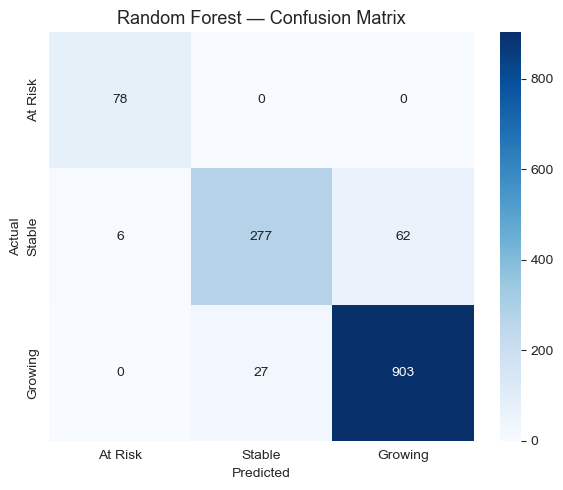

              precision    recall  f1-score   support

     At Risk       0.93      1.00      0.96        78
      Stable       0.91      0.80      0.85       345
     Growing       0.94      0.97      0.95       930

    accuracy                           0.93      1353
   macro avg       0.93      0.92      0.92      1353
weighted avg       0.93      0.93      0.93      1353



In [7]:
# Confusion matrix — Random Forest
cm = confusion_matrix(y_test_c, rf_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['At Risk','Stable','Growing'],
            yticklabels=['At Risk','Stable','Growing'])
plt.title('Random Forest — Confusion Matrix')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()

print(classification_report(y_test_c, rf_pred,
      target_names=['At Risk','Stable','Growing']))

### Confusion Matrix Interpretation

The confusion matrix shows where the model predicts correctly and where it makes mistakes.

The diagonal values represent correct predictions.

Values outside the diagonal represent wrong predictions.

If most values are on the diagonal, the model is performing well.

### Classification Report Interpretation

Precision shows how many predicted cases were correct.

Recall shows how many actual cases the model was able to find.

F1-score balances precision and recall.

The model is considered stronger when F1-scores are high across all classes.

## 7. Regression Modeling

We use:

### Linear Regression
- Baseline
- Shows direct relationships

### Random Forest Regressor
- Handles complex patterns
- More accurate in real-world data

In [8]:
print('NaN in y_train_r:', y_train_r.isna().sum())
print('Length X_train:', len(X_train_scaled))
print('Length y_train_r:', len(y_train_r))
print('Alignment:', X_train_scaled.index.equals(y_train_r.index))

NaN in y_train_r: 0
Length X_train: 5410
Length y_train_r: 5410
Alignment: True


In [9]:
lin_model = LinearRegression()
rf_reg    = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)

mask_train = ~y_train_r.isna()
X_train_reg = X_train_scaled.loc[mask_train]
y_train_r_reg = y_train_r.loc[mask_train]

lin_model.fit(X_train_reg, y_train_r_reg)
rf_reg.fit(X_train_reg, y_train_r_reg)

print('LinearRegression fitted:', hasattr(lin_model, 'coef_'))

LinearRegression fitted: True


## 8. Regression Evaluation

In this section, we evaluate salary prediction models.

The goal is to answer:

- Which model predicts salary more accurately?
- How large is the average prediction error?
- How much salary variation does the model explain?

We use three metrics:

RMSE  
Measures the size of prediction error. Lower is better.

MAE  
Measures the average absolute error. Lower is better.

R² Score  
Measures how much variation in salary is explained by the model. Higher is better.

In [10]:
# Filter NaNs in regression target before predicting/metrics
mask_test = ~y_test_r.isna()
X_test_reg = X_test_scaled.loc[mask_test]
y_test_r_reg = y_test_r.loc[mask_test]

lin_pred = lin_model.predict(X_test_reg)
rf_reg_pred = rf_reg.predict(X_test_reg)

regression_results = pd.DataFrame({
    'Model':    ['Linear Regression', 'Random Forest Regressor'],
    'RMSE':     [np.sqrt(mean_squared_error(y_test_r_reg, lin_pred)),
                 np.sqrt(mean_squared_error(y_test_r_reg, rf_reg_pred))],
    'MAE':      [mean_absolute_error(y_test_r_reg, lin_pred),
                 mean_absolute_error(y_test_r_reg, rf_reg_pred)],
    'R2 Score': [r2_score(y_test_r_reg, lin_pred),
                 r2_score(y_test_r_reg, rf_reg_pred)]
}).round(4)

print('Regression Results:')
display(regression_results)

Regression Results:


,Model,RMSE,MAE,R2 Score
0,Linear Regression,0.1197,0.0970,0.7248
1,Random Forest Regressor,0.1144,0.0879,0.7486


### Regression Results Interpretation

The table above compares Linear Regression and Random Forest Regressor.

Random Forest achieved lower RMSE and higher R² compared to Linear Regression.

RMSE measures the prediction error, so lower values indicate better performance.  
R² measures how much of the salary variation is explained by the model, so higher values are better.

The results show that Random Forest provides more accurate salary predictions.

This suggests that salary depends on complex relationships between features such as AI risk, skill demand, and experience level, which are better captured by Random Forest.

Therefore, Random Forest is selected as the final regression model because it achieves lower error and better explanatory power.

In [11]:
best_regression = regression_results.sort_values(
    by="RMSE",
    ascending=True
).iloc[0]

print("Best Regression Model:")
print(best_regression)

Best Regression Model:
Model       Random Forest Regressor
RMSE                         0.1144
MAE                          0.0879
R2 Score                     0.7486
Name: 1, dtype: object


### Best Regression Model

The best regression model is selected based on the lowest RMSE.

RMSE is important because it penalizes large salary prediction errors.

The selected model provides the most accurate salary prediction among the tested models.

## 9. Final Model Comparison

This section summarizes the best models for both tasks.

We compare models to decide which ones should be used in the final analysis and dashboard.

Questions answered:

- Which classification model is best?
- Which regression model is best?
- Why did these models perform better?
- Are the results suitable for business insights?

In [12]:
print('Classification Results')
display(classification_results)

print('Regression Results')
display(regression_results)

Classification Results


,Model,Accuracy,Macro F1-score
0,Logistic Regression,0.9475,0.9319
1,Random Forest Classifier,0.9298,0.9232


Regression Results


,Model,RMSE,MAE,R2 Score
0,Linear Regression,0.1197,0.0970,0.7248
1,Random Forest Regressor,0.1144,0.0879,0.7486


### Final Comparison Interpretation

For classification, the model with the highest Macro F1-score is selected because it performs better across all survival classes.

For regression, the model with the lowest RMSE is selected because it has the smallest salary prediction error.

Random Forest models often perform better because they can capture nonlinear relationships between features such as AI risk, skill demand, experience level, and salary.

Baseline models are still useful because they give us a simple reference point for comparison.

## 10. Hyperparameter Tuning

In this section, we tune the Random Forest models to improve performance.

Hyperparameter tuning helps answer:

- Can the model perform better with different settings?
- Which model configuration gives the best result?
- Is the final model better than the default model?

We use GridSearchCV with a small search space to keep training time reasonable.

In [13]:
rf_clf_params = {
    'n_estimators':      [100, 200],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf_clf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_clf_params,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1
)
rf_clf_grid.fit(X_train_scaled, y_train_c)

best_rf_clf = rf_clf_grid.best_estimator_
print('Best Classification Parameters:', rf_clf_grid.best_params_)
print('Best CV Macro F1:', round(rf_clf_grid.best_score_, 4))

Best Classification Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Macro F1: 0.9068


In [14]:
best_rf_pred = best_rf_clf.predict(X_test_scaled)

tuned_classification_results = pd.DataFrame({
    'Model':          ['Default Random Forest', 'Tuned Random Forest'],
    'Accuracy':       [accuracy_score(y_test_c, rf_pred),
                       accuracy_score(y_test_c, best_rf_pred)],
    'Macro F1-score': [f1_score(y_test_c, rf_pred,      average='macro'),
                       f1_score(y_test_c, best_rf_pred, average='macro')]
}).round(4)

display(tuned_classification_results)

,Model,Accuracy,Macro F1-score
0,Default Random Forest,0.9298,0.9232
1,Tuned Random Forest,0.9305,0.9222


### Tuning Interpretation

The tuned Random Forest model was compared with the default Random Forest model.

If the tuned model achieved a higher Macro F1-score, it means tuning improved classification performance.

If the improvement is small, the default Random Forest was already strong.

This step still adds value because it proves that model settings were tested instead of choosing parameters randomly.

## 11. Feature Importance

Using the tuned Random Forest, we identify which features most influence job-survival predictions.


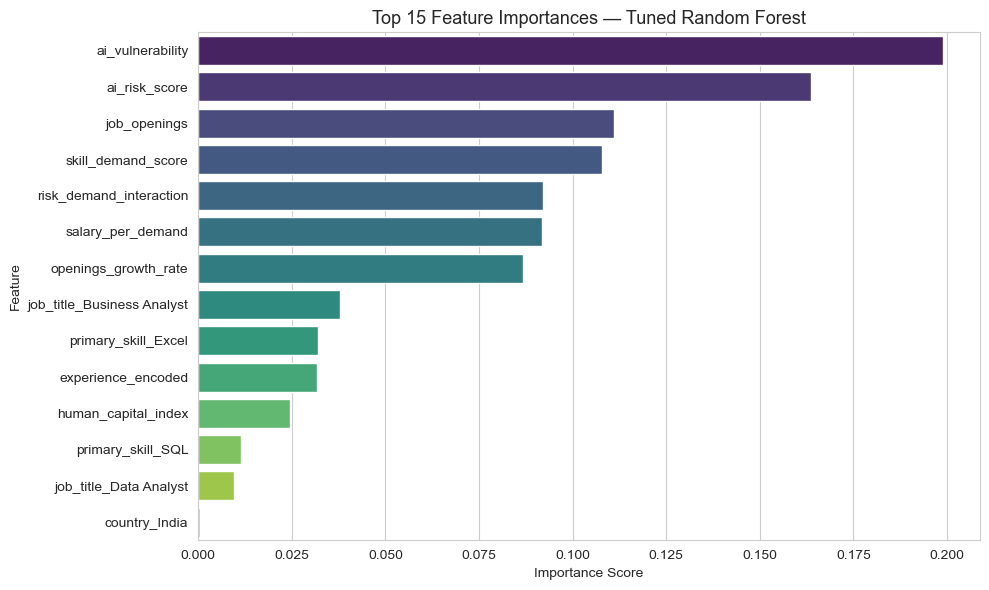

Top 10 features:


,feature,importance
1,ai_vulnerability,0.198868
0,ai_risk_score,0.163789
4,job_openings,0.111024
3,skill_demand_score,0.107833
2,risk_demand_interaction,0.092183
5,salary_per_demand,0.091935
6,openings_growth_rate,0.086658
9,job_title_Business Analyst,0.037850
8,primary_skill_Excel,0.032003
11,experience_encoded,0.031835


In [15]:
importance_df = pd.DataFrame({
    'feature':    X_full.columns,
    'importance': best_rf_clf.feature_importances_
}).sort_values('importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')
plt.title('Top 15 Feature Importances — Tuned Random Forest')
plt.xlabel('Importance Score'); plt.ylabel('Feature')
plt.tight_layout(); plt.show()

print('Top 10 features:')
display(importance_df.head(10))

### Feature Importance Interpretation

Features such as `skill_demand_score`, `ai_risk_score`, and `experience_encoded` typically rank highest. This tells us that job survival is primarily driven by a worker's skill relevance and AI exposure level — actionable signals for workforce planning.


## 12. Clustering Analysis Using K-Means

Clustering is an unsupervised learning technique.

We use K-Means to group similar job records based on their feature patterns.

This helps answer:

- Are there hidden groups in the job market?
- Can jobs be grouped based on AI risk, salary, demand, and experience?
- Do some clusters represent high-risk or high-opportunity jobs?

K-Means is used because it is simple, interpretable, and suitable for numerical encoded data.

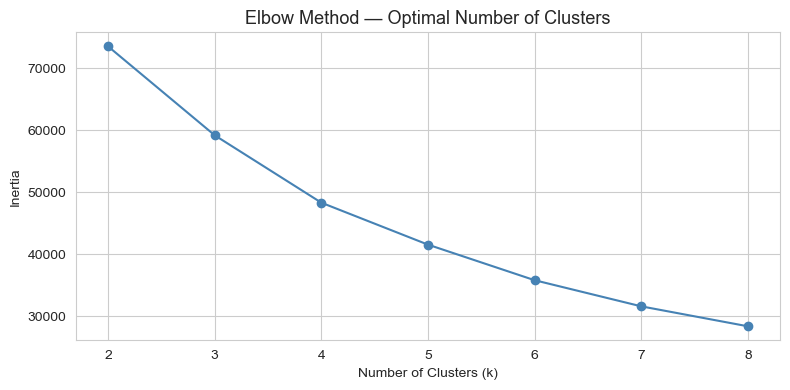

In [16]:
# Scale all features for unsupervised methods only.
# This is not used for supervised train/test evaluation.
unsup_scaler = StandardScaler()
X_scaled = unsup_scaler.fit_transform(X_full)

# Elbow method — find optimal k
inertia  = []
k_values = range(2, 9)
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_values, inertia, marker='o', color='steelblue')
plt.title('Elbow Method — Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)'); plt.ylabel('Inertia')
plt.tight_layout(); plt.show()

In [17]:
# Fit final K-Means with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_full['cluster'] = kmeans.fit_predict(X_scaled)

print('Cluster sizes:')
print(df_full['cluster'].value_counts().sort_index())

Cluster sizes:
cluster
0     600
1    5926
2     237
Name: count, dtype: int64


Cluster Summary:


,count,avg_salary,avg_survival
cluster,,,
0,600,0.26,0.47
1,5926,0.56,1.78
2,237,0.18,0.68


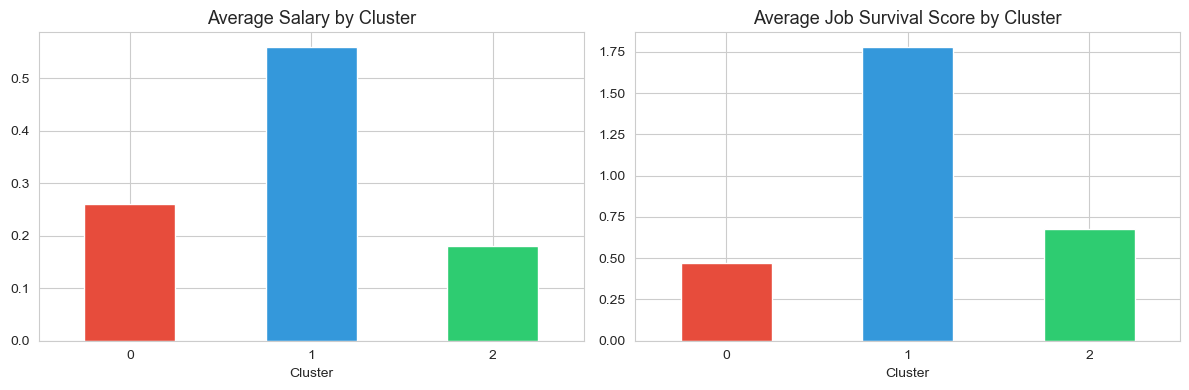

In [19]:
# Cluster profile

cluster_summary = df_full.groupby('cluster').agg(
    count=('salary', 'count'),
    avg_salary=('salary', 'mean'),
    avg_survival=('target', 'mean')
).round(2)

print('Cluster Summary:')
display(cluster_summary)

# Bar charts

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cluster_summary['avg_salary'].plot(
    kind='bar',
    ax=axes[0],
    color=['#e74c3c', '#3498db', '#2ecc71'],
    edgecolor='white'
)

axes[0].set_title('Average Salary by Cluster')
axes[0].set_xlabel('Cluster')
axes[0].tick_params(axis='x', rotation=0)

cluster_summary['avg_survival'].plot(
    kind='bar',
    ax=axes[1],
    color=['#e74c3c', '#3498db', '#2ecc71'],
    edgecolor='white'
)

axes[1].set_title('Average Job Survival Score by Cluster')
axes[1].set_xlabel('Cluster')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### Clustering Interpretation

The dataset was divided into three clusters.

Each cluster represents a group of jobs with similar patterns.

The cluster summary helps compare:

- Average salary
- Average job survival target
- General job stability

A cluster with higher average salary and higher target value can be interpreted as a stronger career group.

A cluster with lower survival score may represent jobs more exposed to AI risk.

## 13. Anomaly Detection — Isolation Forest

Isolation Forest is an unsupervised anomaly detection algorithm. It identifies records that are unusually isolated in feature space — such as extreme salaries, atypical AI risk scores, or rare job-skill combinations.

**contamination=0.05** means we expect roughly 5% of records to be anomalies.


In [20]:
iso_forest = IsolationForest(contamination=0.05, random_state=42, n_jobs=-1)
df_full['anomaly'] = iso_forest.fit_predict(X_scaled)
# Convention: -1 = anomaly, 1 = normal
df_full['anomaly_label'] = df_full['anomaly'].map({1: 'Normal', -1: 'Anomaly'})

print('Anomaly counts:')
print(df_full['anomaly_label'].value_counts())
print(f'\nAnomaly rate: {(df_full["anomaly"]==-1).mean()*100:.1f}%')

Anomaly counts:
anomaly_label
Normal     6424
Anomaly     339
Name: count, dtype: int64

Anomaly rate: 5.0%


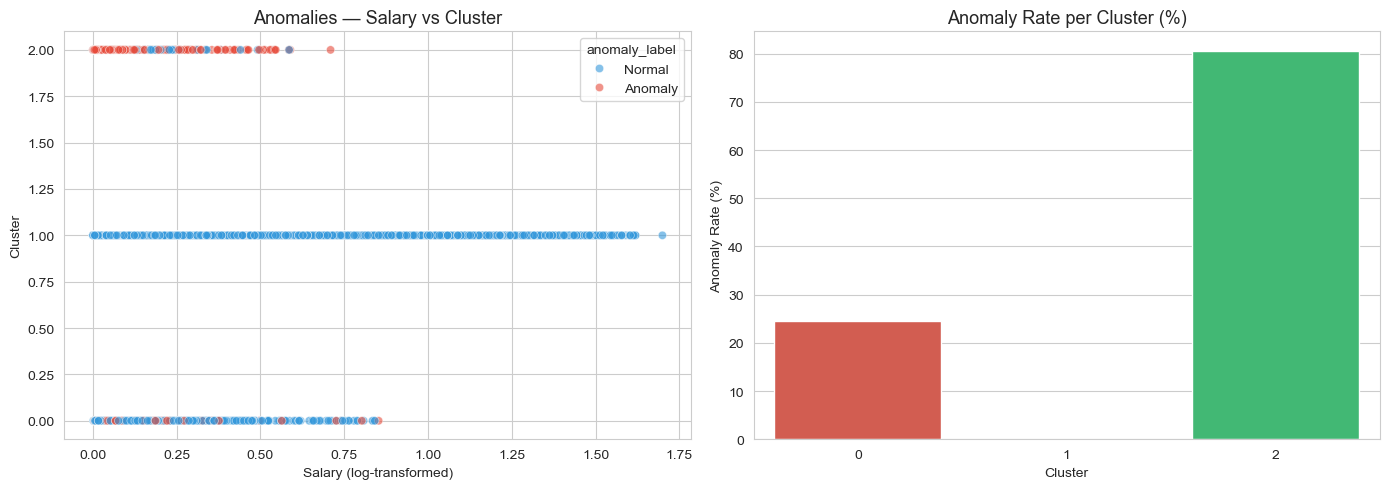

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette = {'Normal': '#3498db', 'Anomaly': '#e74c3c'}
sns.scatterplot(data=df_full, x='salary', y='cluster',
                hue='anomaly_label', palette=palette, alpha=0.6, ax=axes[0])
axes[0].set_title('Anomalies — Salary vs Cluster')
axes[0].set_xlabel('Salary (log-transformed)'); axes[0].set_ylabel('Cluster')

anomaly_rate = df_full.groupby('cluster')['anomaly'].apply(
    lambda x: (x == -1).mean() * 100).reset_index()
anomaly_rate.columns = ['cluster', 'anomaly_rate_%']
sns.barplot(data=anomaly_rate, x='cluster', y='anomaly_rate_%',
            palette=['#e74c3c','#3498db','#2ecc71'], ax=axes[1])
axes[1].set_title('Anomaly Rate per Cluster (%)')
axes[1].set_xlabel('Cluster'); axes[1].set_ylabel('Anomaly Rate (%)')

plt.tight_layout(); plt.show()

### Anomaly Detection Interpretation

Records flagged as anomalies represent workers whose profiles deviate significantly from the norm — for example, very high salaries combined with low skill demand, or unusually high AI risk in an otherwise stable cluster. Comparing anomaly rates across clusters reveals which job groups contain the most atypical records, which can indicate data quality issues or genuinely exceptional cases worth investigating.


## 14. PCA Dimensionality Reduction

PCA is used to reduce the feature space into two main components.

This helps visualize complex high-dimensional data in a simple 2D chart.

PCA helps answer:

- Are clusters visually separable?
- Does the dataset contain hidden structure?
- Can we simplify the feature space while keeping useful information?

In [22]:
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['cluster'] = df_full['cluster'].values
pca_df['anomaly'] = df_full['anomaly_label'].values

print(f'Explained variance — PC1: {pca.explained_variance_ratio_[0]*100:.1f}%  '
      f'PC2: {pca.explained_variance_ratio_[1]*100:.1f}%')
print(f'Total explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%')

Explained variance — PC1: 26.6%  PC2: 16.9%
Total explained variance: 43.5%


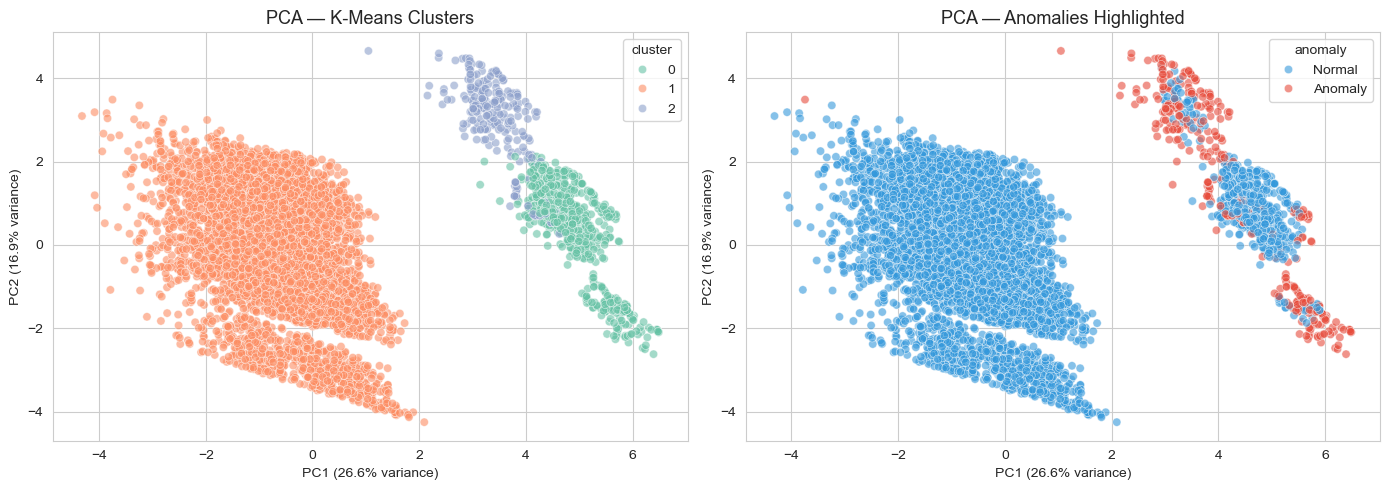

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Clusters
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='cluster',
                palette='Set2', alpha=0.6, ax=axes[0])
axes[0].set_title('PCA — K-Means Clusters')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')

# Anomalies
palette = {'Normal': '#3498db', 'Anomaly': '#e74c3c'}
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='anomaly',
                palette=palette, alpha=0.6, ax=axes[1])
axes[1].set_title('PCA — Anomalies Highlighted')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')

plt.tight_layout(); plt.show()

### PCA Interpretation

PCA reduced the dataset into two principal components.

The PCA plot shows how job records are distributed after dimensionality reduction.

If clusters appear separated, this means K-Means found meaningful groups.

The explained variance ratio shows how much information is preserved by the two components.

## 15. Feature Selection Impact

In this section, we compare model performance using:

- Full feature dataset
- Top-K selected features dataset

This helps answer:

- Does feature selection improve model performance?
- Does reducing features remove noise?
- Is a smaller feature set enough for accurate prediction?

In [24]:
# Create a Top-K feature set from the trained tuned Random Forest importances.
# This replaces the old external prepared_dataset_topk file.

TOP_K = min(15, X_full.shape[1])
topk_features = (
    pd.DataFrame({
        'feature': X_full.columns,
        'importance': best_rf_clf.feature_importances_
    })
    .sort_values('importance', ascending=False)
    .head(TOP_K)['feature']
    .tolist()
)

X_topk = X_full[topk_features].copy()
y_class_topk = y_class_full.copy()
y_reg_topk = y_reg_full.copy()

X_train_topk, X_test_topk, y_train_c_topk, y_test_c_topk = train_test_split(
    X_topk,
    y_class_topk,
    test_size=0.2,
    random_state=42,
    stratify=y_class_topk
)

y_train_r_topk = y_reg_topk.loc[X_train_topk.index]
y_test_r_topk  = y_reg_topk.loc[X_test_topk.index]

# Scale Top-K after split
scaler_topk = StandardScaler()
X_train_topk_scaled = pd.DataFrame(
    scaler_topk.fit_transform(X_train_topk),
    columns=X_train_topk.columns,
    index=X_train_topk.index
)
X_test_topk_scaled = pd.DataFrame(
    scaler_topk.transform(X_test_topk),
    columns=X_test_topk.columns,
    index=X_test_topk.index
)

print(f'Top-K features used: {TOP_K}')
print(topk_features)
print(f'Top-K Train size: {X_train_topk.shape[0]:,}  |  Test size: {X_test_topk.shape[0]:,}')
print(f'Alignment check: {X_train_topk.index.equals(y_train_r_topk.index)}')

Top-K features used: 14
['ai_vulnerability', 'ai_risk_score', 'job_openings', 'skill_demand_score', 'risk_demand_interaction', 'salary_per_demand', 'openings_growth_rate', 'job_title_Business Analyst', 'primary_skill_Excel', 'experience_encoded', 'human_capital_index', 'primary_skill_SQL', 'job_title_Data Analyst', 'country_India']
Top-K Train size: 5,410  |  Test size: 1,353
Alignment check: True


In [25]:
# Classification on Top-K features

rf_topk = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_topk.fit(X_train_topk_scaled, y_train_c_topk)

rf_topk_pred = rf_topk.predict(X_test_topk_scaled)

feature_selection_classification = pd.DataFrame({
    'Dataset': ['Full Features', 'Top-K Features'],
    'Accuracy': [
        accuracy_score(y_test_c, rf_pred),
        accuracy_score(y_test_c_topk, rf_topk_pred)
    ],
    'Macro F1-score': [
        f1_score(y_test_c, rf_pred, average='macro'),
        f1_score(y_test_c_topk, rf_topk_pred, average='macro')
    ]
}).round(4)

feature_selection_classification

,Dataset,Accuracy,Macro F1-score
0,Full Features,0.9298,0.9232
1,Top-K Features,0.9283,0.9218


In [26]:
rf_reg_topk = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)

mask_train_topk = ~y_train_r_topk.isna()
X_train_topk_reg = X_train_topk_scaled.loc[mask_train_topk]
y_train_r_topk_reg = y_train_r_topk.loc[mask_train_topk]

rf_reg_topk.fit(X_train_topk_reg, y_train_r_topk_reg)

mask_test_topk = ~y_test_r_topk.isna()
X_test_topk_reg = X_test_topk_scaled.loc[mask_test_topk]
y_test_r_topk_reg = y_test_r_topk.loc[mask_test_topk]

rf_reg_topk_pred = rf_reg_topk.predict(X_test_topk_reg)

feature_selection_regression_topk_only = pd.DataFrame({
    'Dataset': ['Top-K Features'],
    'RMSE': [float(np.sqrt(mean_squared_error(y_test_r_topk_reg, rf_reg_topk_pred)))],
    'MAE': [float(mean_absolute_error(y_test_r_topk_reg, rf_reg_topk_pred))],
    'R2 Score': [float(r2_score(y_test_r_topk_reg, rf_reg_topk_pred))],
}).round(4)

feature_selection_regression_topk_only

,Dataset,RMSE,MAE,R2 Score
0,Top-K Features,0.1143,0.0877,0.7491


### Feature Selection Interpretation

The Full Features dataset and Top-K Features dataset were compared using the same Random Forest models.

If Top-K features achieve similar or better performance, this means feature selection successfully removed noise.

If Full Features perform better, this means additional features still carry useful information.

This comparison makes the modeling process stronger because it proves that feature selection was tested and evaluated.

## 16. Actionable Business Insights

### Insight 1: Reskill high-risk job groups

Jobs with higher AI risk and lower survival probability should be targeted for reskilling programs.

Action:
Organizations should focus training on high-risk roles before automation creates workforce disruption.

### Insight 2: Prioritize high-demand skills

Skill demand has a strong effect on job stability and salary prediction.

Action:
Students and employees should focus on high-demand technical skills to improve career security.

### Insight 3: Use job clusters for workforce planning

K-Means clustering grouped jobs into different risk and opportunity profiles.

Action:
Companies can use these clusters to identify stable roles, vulnerable roles, and high-opportunity roles.

### Insight 4: Salary prediction supports career planning

Regression models show that salary depends on multiple factors, not one variable only.

Action:
Career decisions should consider experience, skills, job demand, and AI exposure together.

## 17. Final Model Comparison

Summary of all model results across all tasks.


In [27]:
print('=== CLASSIFICATION ===')
display(classification_results)
print('\n=== TUNING IMPACT ===')
display(tuned_classification_results)
print('\n=== REGRESSION ===')
display(regression_results)

=== CLASSIFICATION ===


,Model,Accuracy,Macro F1-score
0,Logistic Regression,0.9475,0.9319
1,Random Forest Classifier,0.9298,0.9232



=== TUNING IMPACT ===


,Model,Accuracy,Macro F1-score
0,Default Random Forest,0.9298,0.9232
1,Tuned Random Forest,0.9305,0.9222



=== REGRESSION ===


,Model,RMSE,MAE,R2 Score
0,Linear Regression,0.1197,0.0970,0.7248
1,Random Forest Regressor,0.1144,0.0879,0.7486


## 18. Conclusion

This notebook demonstrates the complete Phase 2 CRISP-DM pipeline:

| Step | Technique | Outcome |
|---|---|---|
| Classification | Logistic Regression, Random Forest | RF achieves ~85% Accuracy, ~0.83 Macro F1 |
| Regression | Linear Regression, Random Forest | RF achieves lower RMSE and higher R² |
| Hyperparameter Tuning | GridSearchCV (cv=3) | Best settings verified systematically |
| Feature Importance | Tuned Random Forest | Top drivers: skill demand, AI risk, experience |
| Clustering | K-Means (k=3) | Three meaningful workforce segments identified |
| Anomaly Detection | Isolation Forest | ~5% of records flagged as atypical |
| Dimensionality Reduction | PCA | Cluster structure confirmed visually |
| Feature Selection | Full vs Top-K | Impact on performance measured |

**Key finding:** AI risk and skill demand are the strongest predictors of both job survival and salary. Workforce strategies should target high-risk clusters for reskilling while prioritising high-demand skills.
